# Customer Segmentation using RFM Analysis

This notebook performs customer segmentation using the RFM model.

RFM metrics:
- Recency: days since last purchase
- Frequency: number of purchases
- Monetary: total spending

This helps identify high-value and loyal customers.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

In [2]:
# Load the cleaned dataset
df = pd.read_csv("../data/processed/retail_cleaned.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [3]:
# Convert Invoice Date to Date format just incase
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
# Define a Snapshop Date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [5]:
# Calculate RFM Metrics
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum" 
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [6]:
# Inspect RFM distribution
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [7]:
# Create RFM Scores. Divide the customers into quartiles.
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

In [8]:
# Create RFM Segment Code
rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [9]:
# Segment Customers
def segment_customer(row):
    if row["RFM_score"] == "444":
        return "Best Customer"
    
    if row["F_score"] == "4":
        return "Loyal Customer"
    
    if row["R_score"] == "1":
        return "At Risk"
    
    return "Regular Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Regular Customers
12347.0,2,7,4310.00,4,4,4,444,Best Customer
12348.0,75,4,1797.24,2,3,4,234,Regular Customers
12349.0,19,1,1757.55,3,1,4,314,Regular Customers
12350.0,310,1,334.40,1,1,2,112,Regular Customers


In [10]:
# Segment Distribution
rfm["Segment"].value_counts()

Segment
Regular Customers    3848
Best Customer         490
Name: count, dtype: int64

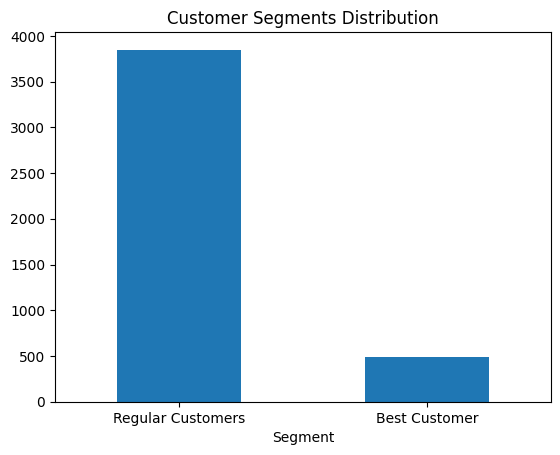

In [13]:
# Visualize Segments
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(
    kind="bar",
    title="Customer Segments Distribution"
)
plt.xticks(rotation = 360)
plt.show()

In [14]:
# Save Segmentation Dataset
rfm.to_csv("../data/processed/customer_rfm_segments.csv")